 # **TELCO CUSTOMER CHURN - ML PROJECT**

#### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

#### LOAD DATA

In [ ]:
df = pd.read_excel('Telco_customer_churn.xlsx')
print("Shape:", df.shape)
print(df.head(3))

Shape: (7043, 33)
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   

  Paperless Billing    Payment Method  Monthly Charges Total Charges  \
0               Yes      Mailed check            53.85        108.15   
1               Yes  Electronic check            70.70        151.65   
2               Yes  Electronic check            99.65         820.5   

  Churn Label Churn Value Churn Score  CLTV                  Churn Reas

## DATA CLEANING

#### Drop columns that are not useful for ML

In [ ]:
cols_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'City',
                'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
                'Churn Score', 'CLTV', 'Churn Reason', 'Churn Label']
df.drop(columns=cols_to_drop, inplace=True)

#### Fix Total Charges column

In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

#### Remove duplicate rows

In [ ]:
df.drop_duplicates(inplace=True)
print("Missing values:\n", df.isnull().sum())

Missing values:
 Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
dtype: int64


## ENCODING

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
print("Encoding done!")
print(df.head(3))

Encoding done!
   Gender  Senior Citizen  Partner  Dependents  Tenure Months  Phone Service  \
0       1               0        0           0              2              1   
1       0               0        0           1              2              1   
2       0               0        0           1              8              1   

   Multiple Lines  Internet Service  Online Security  Online Backup  \
0               0                 0                2              2   
1               0                 1                0              0   
2               2                 1                0              0   

   Device Protection  Tech Support  Streaming TV  Streaming Movies  Contract  \
0                  0             0             0                 0         0   
1                  0             0             0                 0         0   
2                  2             0             2                 2         0   

   Paperless Billing  Payment Method  Monthly Charges  Tot

## EDA - EXPLORATORY DATA ANALYSIS

#### Plot 1: How many customers churned?

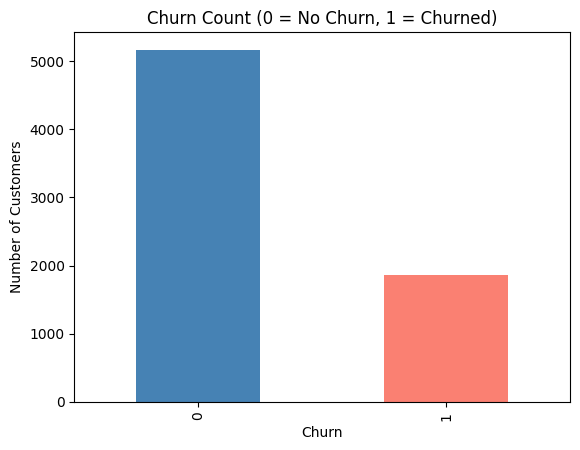

In [ ]:
df['Churn Value'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Count (0 = No Churn, 1 = Churned)')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

#### Plot 2: Monthly charges - do churners pay more?

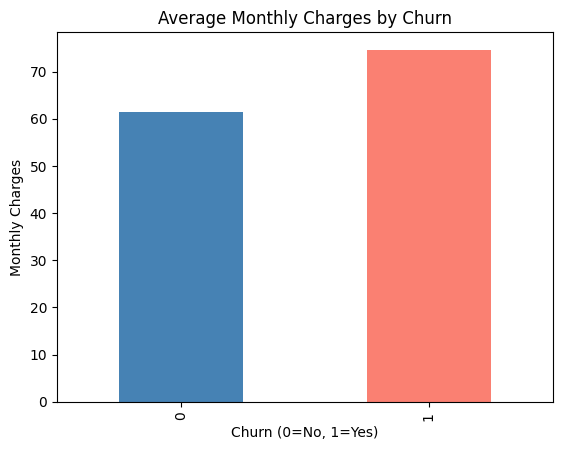

In [ ]:
df.groupby('Churn Value')['Monthly Charges'].mean().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Average Monthly Charges by Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Monthly Charges')
plt.show()

#### Plot 3: Tenure - how long do churners stay?

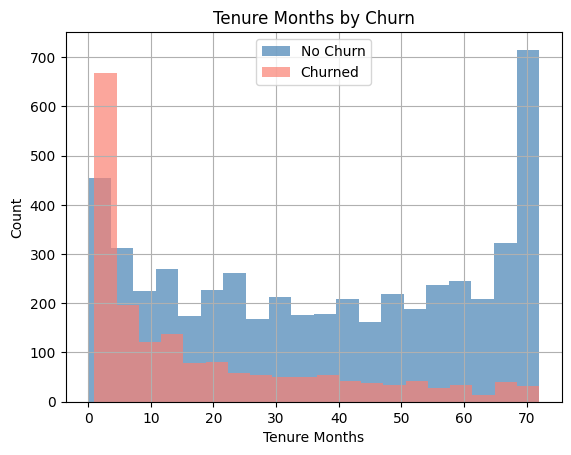

In [ ]:
df[df['Churn Value'] == 0]['Tenure Months'].hist(alpha=0.7, label='No Churn', bins=20, color='steelblue')
df[df['Churn Value'] == 1]['Tenure Months'].hist(alpha=0.7, label='Churned', bins=20, color='salmon')
plt.title('Tenure Months by Churn')
plt.xlabel('Tenure Months')
plt.ylabel('Count')
plt.legend()
plt.show()

#### Plot 4: Correlation heatmap

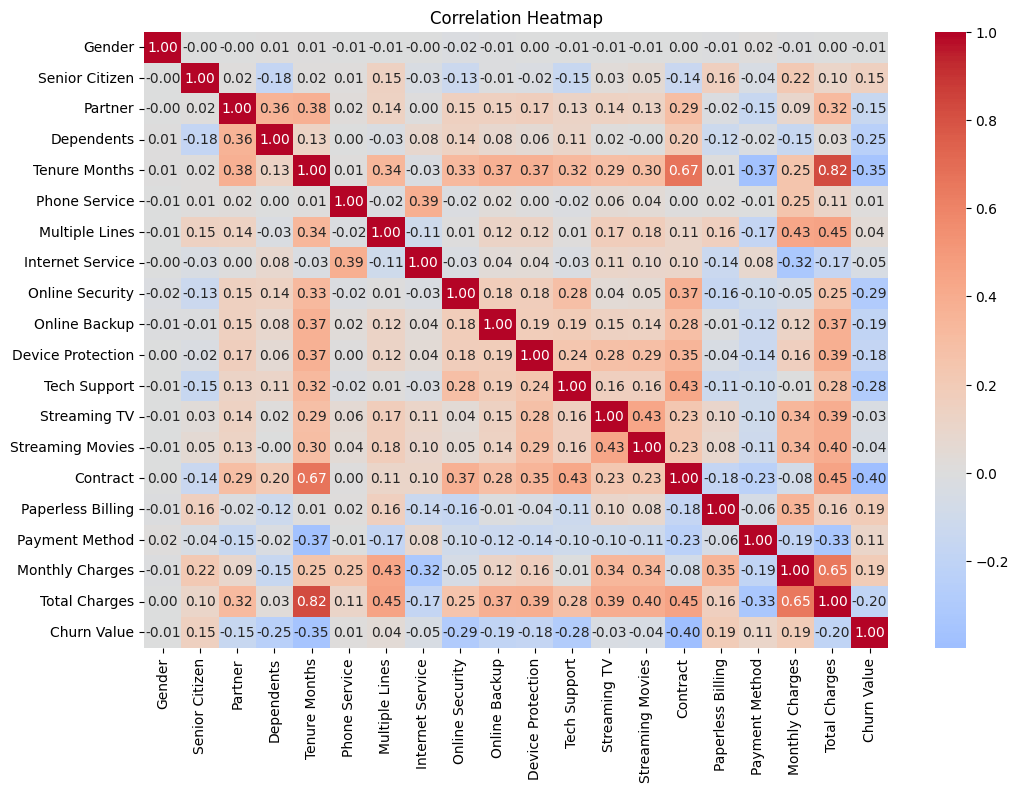

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## FEATURE SELECTION

In [ ]:
X = df.drop(columns=['Churn Value'])
y = df['Churn Value']

#### Use a simple Random Forest to find which features matter most

In [ ]:
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X, y)

RandomForestClassifier(random_state=42)

#### Get feature importances and pick top 15

In [ ]:
importances = pd.Series(rf_temp.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15).index.tolist()
print("Top 15 features:", top_features)

Top 15 features: ['Total Charges', 'Monthly Charges', 'Tenure Months', 'Contract', 'Payment Method', 'Online Security', 'Tech Support', 'Dependents', 'Gender', 'Internet Service', 'Online Backup', 'Paperless Billing', 'Partner', 'Multiple Lines', 'Device Protection']


In [ ]:
X = X[top_features]

#### TRAIN TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5616, 15)
Test size: (1405, 15)


#### RANDOM FOREST

In [ ]:
rf = RandomForestClassifier(n_estimators=200,max_depth=10,class_weight='balanced',random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churned']))


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.81      0.84      1033
     Churned       0.57      0.70      0.63       372

    accuracy                           0.78      1405
   macro avg       0.72      0.75      0.73      1405
weighted avg       0.80      0.78      0.79      1405



#### Confusion Matrix

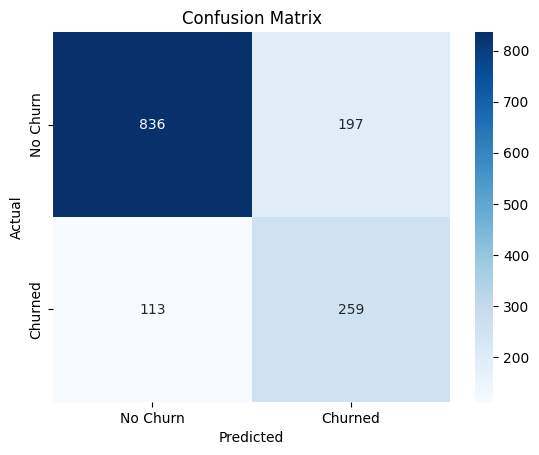

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['No Churn', 'Churned'],yticklabels=['No Churn', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#### HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],'class_weight': ['balanced']}

In [ ]:
rf_tuned = RandomizedSearchCV(RandomForestClassifier(random_state=42),param_distributions=param_grid,n_iter=20,cv=3,scoring='recall',random_state=42)
rf_tuned.fit(X_train, y_train)
print("Best Parameters:", rf_tuned.best_params_)
print("Best Recall Score:", round(rf_tuned.best_score_ * 100, 2), "%")

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5, 'class_weight': 'balanced'}
Best Recall Score: 80.34 %


In [ ]:
best_rf = rf_tuned.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print("\nAfter Tuning:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn', 'Churned']))


After Tuning:
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1033
     Churned       0.53      0.80      0.63       372

    accuracy                           0.76      1405
   macro avg       0.72      0.77      0.73      1405
weighted avg       0.81      0.76      0.77      1405



## CROSS VALIDATION

#### We split data into 5 parts, train on 4, test on 1, repeat 5 times

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_recall = cross_val_score(best_rf, X, y, cv=skf, scoring='recall')
cv_accuracy = cross_val_score(best_rf, X, y, cv=skf, scoring='accuracy')

In [ ]:
print("Cross Validation Recall (5 folds):", [round(x*100,1) for x in cv_recall])
print("Mean Recall:", round(cv_recall.mean()*100, 2), "%")
print("Mean Accuracy:", round(cv_accuracy.mean()*100, 2), "%")

Cross Validation Recall (5 folds): [np.float64(81.5), np.float64(81.5), np.float64(80.3), np.float64(79.0), np.float64(81.4)]
Mean Recall: 80.72 %
Mean Accuracy: 75.79 %


#### Plot cross validation results

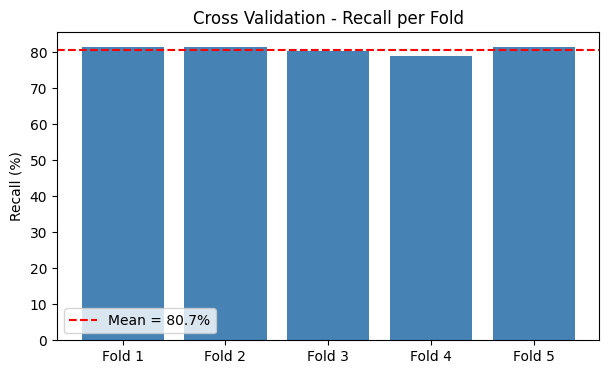

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar([f'Fold {i+1}' for i in range(5)], cv_recall * 100, color='steelblue')
plt.axhline(cv_recall.mean() * 100, color='red', linestyle='--', label=f'Mean = {cv_recall.mean()*100:.1f}%')
plt.title('Cross Validation - Recall per Fold')
plt.ylabel('Recall (%)')
plt.legend()
plt.show()

#### ROC - AUC SCORE

In [ ]:
y_prob = best_rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

ROC-AUC Score: 0.8492


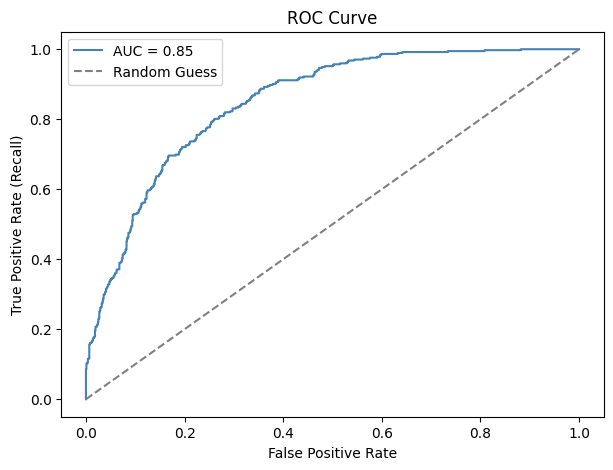

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

## CUSTOMER SEGMENTATION WITH K-MEANS

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
seg_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Contract', 'Churn Value']
df_seg = df[seg_features].dropna()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_seg)

####Find best K using Elbow Method

In [ ]:
inertia = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

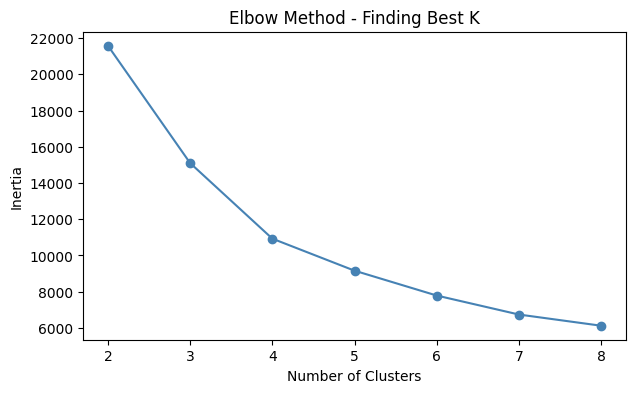

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(2, 9), inertia, marker='o', color='steelblue')
plt.title('Elbow Method - Finding Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_seg['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
print("Model Summary:")
print(f"  Recall   : {round(cv_recall.mean()*100, 1)}%")
print(f"  Accuracy : {round(cv_accuracy.mean()*100, 1)}%")
print(f"  ROC-AUC  : {round(auc*100, 1)}%")

Model Summary:
  Recall   : 80.7%
  Accuracy : 75.8%
  ROC-AUC  : 84.9%
